In [1]:
from ultralytics import YOLO

def main():
    model = YOLO("runs/segment/runs/coffee-seg-final/weights/best.pt")

    results = model.predict(
        source="dataset/valid/images",
        save=True,
        conf=0.4
    )

if __name__ == "__main__":
    main()


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2536 d:\dhiya_skirpsi\model_YOLO11-seg\dataset\valid\images\Broken-chipped-and-cut_rotated_180_jpg.rf.99e2f990f70b63cf2aad538330fdc56c.jpg: 608x640 36 brokens, 42.4ms
image 2/2536 d:\dhiya_skirpsi\model_YOLO11-seg\dataset\valid\images\Broken-chipped-and-cut_rotated_180_jpg.rf.ccd7f28cc8a88df6fb6d2e1ef09496e4.jpg: 608x640 36 brokens, 11.0ms
image 3/2536 d:\dhiya_skirpsi\model_YOLO11-seg\dataset\valid\images\Broken_02_rotated_270_jpg.rf.662eddc49214a4


image 1/1 D:\dhiya_skirpsi\model_YOLO11-seg\dataset\test\images\Severe-Insect-Damange_21_rotated_90_jpg.rf.ceb13f08e159d33ec4107ea479cc9b85.jpg: 640x640 1 insect_severe, 125.0ms
Speed: 5.8ms preprocess, 125.0ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)


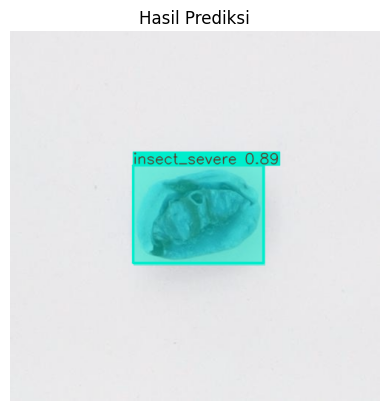

File diuji: D:/dhiya_skirpsi/model_YOLO11-seg/dataset/test/images/Severe-Insect-Damange_21_rotated_90_jpg.rf.ceb13f08e159d33ec4107ea479cc9b85.jpg


In [3]:
#test manual dengan ground truth
from ultralytics import YOLO
from tkinter import Tk
from tkinter.filedialog import askopenfilename
import matplotlib.pyplot as plt

def upload_and_test():
    root = Tk()
    root.withdraw()

    file_path = askopenfilename(
        title="Pilih gambar",
        filetypes=[("Image files", "*.jpg *.png *.jpeg")]
    )

    if not file_path:
        print("Tidak ada file dipilih")
        return

    model = YOLO("runs/segment/runs/coffee-seg/weights/best.pt")

    results = model.predict(
        source=file_path,
        conf=0.4,
        save=False,
        show=True
    )

  
    # Ambil hasil pertama
    result = results[0]

    # Plot hasil (sudah ada bounding box + mask)
    img = result.plot()

    # Tampilkan di output (Jupyter / script)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Hasil Prediksi")
    plt.show()

    print(f"File diuji: {file_path}")

if __name__ == "__main__":
    upload_and_test()

In [5]:
#Hitung mIoU dan Dice
import torch
import numpy as np
from ultralytics import YOLO
import cv2
import os

# ==== CONFIG ====
MODEL_PATH = "runs/segment/runs/coffee-seg-final/weights/best.pt"
IMAGE_DIR = "dataset/test/images"
LABEL_DIR = "dataset/test/labels"

# ==== LOAD MODEL ====
model = YOLO(MODEL_PATH)

def polygon_to_mask(img_shape, polygons):
    """Convert YOLO polygon ke mask"""
    mask = np.zeros(img_shape[:2], dtype=np.uint8)
    for poly in polygons:
        pts = np.array(poly, dtype=np.int32)
        cv2.fillPoly(mask, [pts], 1)
    return mask

def compute_metrics(pred_mask, gt_mask):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)

    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()

    iou = intersection / union if union != 0 else 0
    dice = (2 * intersection) / (pred_mask.sum() + gt_mask.sum()) if (pred_mask.sum() + gt_mask.sum()) != 0 else 0

    return iou, dice

ious = []
dices = []

# ==== LOOP SEMUA IMAGE ====
for img_name in os.listdir(IMAGE_DIR):
    img_path = os.path.join(IMAGE_DIR, img_name)
    label_path = os.path.join(LABEL_DIR, img_name.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)

    # ===== PREDICTION =====
    results = model.predict(img_path, conf=0.4, verbose=False)
    r = results[0]

    # ===== PRED MASK =====
    if r.masks is not None:
        pred_mask = r.masks.data[0].cpu().numpy()
        pred_mask = cv2.resize(pred_mask, (img.shape[1], img.shape[0]))
        pred_mask = (pred_mask > 0.5).astype(np.uint8)
    else:
        pred_mask = np.zeros(img.shape[:2], dtype=np.uint8)

    # ===== GT MASK =====
    gt_mask = np.zeros(img.shape[:2], dtype=np.uint8)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        polygons = []
        for line in lines:
            parts = list(map(float, line.strip().split()))
            coords = parts[1:]
            pts = np.array(coords).reshape(-1, 2)

            # convert normalized → pixel
            pts[:, 0] *= img.shape[1]
            pts[:, 1] *= img.shape[0]
            polygons.append(pts)

        gt_mask = polygon_to_mask(img.shape, polygons)

    # ===== METRICS =====
    iou, dice = compute_metrics(pred_mask, gt_mask)
    ious.append(iou)
    dices.append(dice)

# ==== FINAL RESULT ====
print("\n📊 HASIL AKHIR:")
print(f"Mean IoU  : {np.mean(ious):.4f}")
print(f"Mean Dice : {np.mean(dices):.4f}")


📊 HASIL AKHIR:
Mean IoU  : 0.8766
Mean Dice : 0.9205
